# Experiment 3: Does Vanilla InfoNCE Hurt Well-Aligned Layers?

**Goal:** Show that uniform fine-tuning (vanilla InfoNCE, same LR for all layers) improves poorly-aligned layers but damages well-aligned middle layers. This is the key empirical motivation for our adaptive method.

**Setup:**
- Model: XLM-RoBERTa base
- Training: InfoNCE contrastive loss, OPUS-100 EN-ES, uniform LR=2e-5, 2000 steps
- Evaluation: Layer-wise Procrustes, CKA, cosine similarity + isotropy on FLORES-200 EN-ES
- Compare: pretrained baseline → after vanilla fine-tuning

**What we hope to see:** CKA drops at layers 6–8 (well-aligned middle layers damaged), improves slightly at layers 1–2.

In [3]:
# Install dependencies
!pip install -q transformers datasets torch

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import copy

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [5]:
from huggingface_hub import notebook_login
notebook_login()

## Model + Data Utilities

In [6]:
# ── Model ─────────────────────────────────────────────────────────────────────

class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=2048, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class XLMRWrapper(nn.Module):
    def __init__(self, model_name='xlm-roberta-base'):
        super().__init__()
        self.model = XLMRobertaModel.from_pretrained(model_name)
        self.projection = ProjectionHead(768, 2048, 256)

    def forward(self, input_ids, attention_mask):
        """Returns projected embedding for contrastive loss."""
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self._mean_pool(out.last_hidden_state, attention_mask)
        return self.projection(pooled)

    def get_all_layer_reps(self, input_ids, attention_mask):
        """Raw mean-pooled reps for all 12 layers (for alignment scoring)."""
        out = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        return [self._mean_pool(h, attention_mask) for h in out.hidden_states[1:]]

    @staticmethod
    def _mean_pool(hidden, mask):
        m = mask.unsqueeze(-1).float()
        return F.normalize((hidden * m).sum(1) / m.sum(1).clamp(min=1e-9), dim=-1)


# ── Data ──────────────────────────────────────────────────────────────────────

tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')

def collate(pairs, max_length=128):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc


def load_flores_pairs(tgt_lang_code, split='dev', n=None):
    src = load_dataset('openlanguagedata/flores_plus', 'eng_Latn', split=split)
    tgt = load_dataset('openlanguagedata/flores_plus', tgt_lang_code, split=split)
    pairs = [(s['text'], t['text']) for s, t in zip(src, tgt)]
    return pairs[:n] if n else pairs


def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        yield ex['translation'][src_lang], ex['translation'][tgt_lang]


print('Utilities loaded.')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Utilities loaded.


## Alignment Scoring Utilities

In [7]:
def procrustes_score(X, Y):
    """1 - Procrustes distance/2, range [0,1], higher = better aligned."""
    X = X - X.mean(0); X = X / torch.linalg.norm(X, ord='fro').clamp(min=1e-9)
    Y = Y - Y.mean(0); Y = Y / torch.linalg.norm(Y, ord='fro').clamp(min=1e-9)
    U, _, Vt = torch.linalg.svd(Y.T @ X)
    W = U @ Vt
    return float(1.0 - torch.linalg.norm(X - Y @ W, ord='fro').item() / 2.0)

def cosine_score(X, Y):
    """Mean cosine similarity of matched pairs."""
    return float((F.normalize(X, dim=-1) * F.normalize(Y, dim=-1)).sum(-1).mean().item())

def cka_score(X, Y):
    """Linear CKA, range [0,1]."""
    X = X - X.mean(0); Y = Y - Y.mean(0)
    num = torch.linalg.norm(Y.T @ X, ord='fro') ** 2
    denom = torch.linalg.norm(X.T @ X, ord='fro') * torch.linalg.norm(Y.T @ Y, ord='fro')
    return float((num / denom.clamp(min=1e-9)).item())

def intra_cosine(X):
    """Mean off-diagonal cosine similarity within one language (isotropy proxy)."""
    X_norm = F.normalize(X, dim=-1)
    sim = X_norm @ X_norm.T
    N = sim.size(0)
    off = sim.masked_fill(torch.eye(N, dtype=torch.bool), 0.0)
    return float(off.sum().item() / (N * (N - 1)))


@torch.no_grad()
def run_alignment_check(model, pairs, batch_size=256, label=''):
    """Compute per-layer alignment metrics. Returns dict of lists."""
    model.eval()
    src_enc, tgt_enc = collate(pairs[:batch_size])
    src_reps = model.get_all_layer_reps(
        src_enc['input_ids'].to(DEVICE), src_enc['attention_mask'].to(DEVICE))
    tgt_reps = model.get_all_layer_reps(
        tgt_enc['input_ids'].to(DEVICE), tgt_enc['attention_mask'].to(DEVICE))

    results = {'procrustes': [], 'cosine': [], 'cka': [], 'intra_cos': []}
    for src_rep, tgt_rep in zip(src_reps, tgt_reps):
        X, Y = src_rep.cpu(), tgt_rep.cpu()
        results['procrustes'].append(procrustes_score(X, Y))
        results['cosine'].append(cosine_score(X, Y))
        results['cka'].append(cka_score(X, Y))
        results['intra_cos'].append(intra_cosine(X))

    if label:
        print(f'\n--- {label} ---')
        print(f'{"Layer":>6}  {"Procrustes":>12}  {"Cosine":>10}  {"CKA":>10}  {"Intra-cos":>10}')
        print('-' * 60)
        for i in range(12):
            print(f'{i+1:>6}  {results["procrustes"][i]:>12.4f}  '
                  f'{results["cosine"][i]:>10.4f}  '
                  f'{results["cka"][i]:>10.4f}  '
                  f'{results["intra_cos"][i]:>10.4f}')

    model.train()
    return results


print('Scoring utilities loaded.')

Scoring utilities loaded.


## Step 1: Load Model + Measure Pretrained Alignment

In [8]:
print('Loading XLM-R...')
model = XLMRWrapper('xlm-roberta-base').to(DEVICE)

print('Loading FLORES-200 EN-ES dev pairs...')
eval_pairs = load_flores_pairs('spa_Latn', split='dev')
print(f'  {len(eval_pairs)} pairs loaded')

# Measure alignment BEFORE fine-tuning
results_before = run_alignment_check(model, eval_pairs, label='PRETRAINED (before fine-tuning)')

Loading XLM-R...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

spa_Latn.jsonl: 0.00B [00:00, ?B/s]

spa_Latn.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

  997 pairs loaded

--- PRETRAINED (before fine-tuning) ---
 Layer    Procrustes      Cosine         CKA   Intra-cos
------------------------------------------------------------
     1        0.7034      0.8762      0.6929      0.8782
     2        0.7180      0.9644      0.7425      0.9573
     3        0.7282      0.9803      0.7607      0.9698
     4        0.7442      0.9801      0.7956      0.9623
     5        0.7662      0.9800      0.8251      0.9583
     6        0.7819      0.9775      0.8374      0.9522
     7        0.7844      0.9814      0.8438      0.9601
     8        0.7840      0.9808      0.8444      0.9608
     9        0.7774      0.9850      0.8359      0.9672
    10        0.7747      0.9849      0.8286      0.9684
    11        0.7693      0.9844      0.8144      0.9698
    12        0.7226      0.9976      0.6718      0.9969


## Step 2: Vanilla InfoNCE Fine-Tuning (2000 steps, uniform LR)

In [9]:
# ── Config ────────────────────────────────────────────────────────────────────
MAX_STEPS    = 2000
BATCH_SIZE   = 32
LR           = 2e-5
TEMPERATURE  = 0.07
WARMUP_STEPS = 200
LOG_EVERY    = 100

# ── Loss ──────────────────────────────────────────────────────────────────────
def infonce_loss(z_src, z_tgt, tau=TEMPERATURE):
    sim = z_src @ z_tgt.T / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2.0

# ── Optimizer + scheduler ─────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=MAX_STEPS)

# ── Training loop ─────────────────────────────────────────────────────────────
model.train()
train_iter = opus_stream('en-es')
batch_buffer = []
losses = []
step = 0

print(f'Starting vanilla InfoNCE fine-tuning for {MAX_STEPS} steps...')
print(f'  Batch size: {BATCH_SIZE}, LR: {LR}, Temperature: {TEMPERATURE}')
print(f'  Uniform LR across all layers — no adaptive mechanism')

for src_text, tgt_text in train_iter:
    batch_buffer.append((src_text, tgt_text))
    if len(batch_buffer) < BATCH_SIZE:
        continue

    src_enc, tgt_enc = collate(batch_buffer)
    batch_buffer = []

    src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
    tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}

    z_src = model(src_enc['input_ids'], src_enc['attention_mask'])
    z_tgt = model(tgt_enc['input_ids'], tgt_enc['attention_mask'])
    loss = infonce_loss(z_src, z_tgt)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    step += 1
    losses.append(loss.item())

    if step % LOG_EVERY == 0:
        avg = sum(losses[-LOG_EVERY:]) / LOG_EVERY
        print(f'  step {step:>4}/{MAX_STEPS}  loss={avg:.4f}')

    if step >= MAX_STEPS:
        break

print('\nTraining complete.')

Starting vanilla InfoNCE fine-tuning for 2000 steps...
  Batch size: 32, LR: 2e-05, Temperature: 0.07
  Uniform LR across all layers — no adaptive mechanism


README.md: 0.00B [00:00, ?B/s]

  step  100/2000  loss=3.2667
  step  200/2000  loss=1.1290
  step  300/2000  loss=0.3672
  step  400/2000  loss=0.2915
  step  500/2000  loss=0.2658
  step  600/2000  loss=0.2608
  step  700/2000  loss=0.2475
  step  800/2000  loss=0.2414
  step  900/2000  loss=0.2363
  step 1000/2000  loss=0.2176
  step 1100/2000  loss=0.2173
  step 1200/2000  loss=0.1894
  step 1300/2000  loss=0.1853
  step 1400/2000  loss=0.2025
  step 1500/2000  loss=0.1787
  step 1600/2000  loss=0.2165
  step 1700/2000  loss=0.1892
  step 1800/2000  loss=0.1978
  step 1900/2000  loss=0.2215
  step 2000/2000  loss=0.1862

Training complete.


## Step 3: Measure Alignment After Fine-Tuning

In [10]:
results_after = run_alignment_check(model, eval_pairs, label='AFTER vanilla InfoNCE (2000 steps)')


--- AFTER vanilla InfoNCE (2000 steps) ---
 Layer    Procrustes      Cosine         CKA   Intra-cos
------------------------------------------------------------
     1        0.7032      0.8285      0.6624      0.8430
     2        0.7156      0.9586      0.7182      0.9515
     3        0.7306      0.9787      0.7509      0.9667
     4        0.7468      0.9793      0.7924      0.9599
     5        0.7721      0.9796      0.8285      0.9505
     6        0.7897      0.9817      0.8472      0.9483
     7        0.7949      0.9853      0.8607      0.9560
     8        0.8000      0.9864      0.8728      0.9550
     9        0.8070      0.9909      0.8874      0.9627
    10        0.8247      0.9907      0.9084      0.9437
    11        0.8325      0.9872      0.9195      0.8915
    12        0.8126      0.9407      0.8320      0.5568


## Step 4: Before vs. After Comparison

In [11]:
layers = list(range(1, 13))

print('\n=== DELTA (after - before) ===')
print(f'{"Layer":>6}  {"ΔCKA":>10}  {"ΔProcrustes":>12}  {"ΔIntra-cos":>12}')
print('-' * 50)
for i in range(12):
    d_cka   = results_after['cka'][i]       - results_before['cka'][i]
    d_proc  = results_after['procrustes'][i] - results_before['procrustes'][i]
    d_intra = results_after['intra_cos'][i]  - results_before['intra_cos'][i]
    flag = '← damaged' if d_cka < -0.01 else ('← improved' if d_cka > 0.01 else '')
    print(f'{i+1:>6}  {d_cka:>+10.4f}  {d_proc:>+12.4f}  {d_intra:>+12.4f}  {flag}')


=== DELTA (after - before) ===
 Layer        ΔCKA   ΔProcrustes    ΔIntra-cos
--------------------------------------------------
     1     -0.0305       -0.0002       -0.0352  ← damaged
     2     -0.0243       -0.0024       -0.0058  ← damaged
     3     -0.0097       +0.0024       -0.0030  
     4     -0.0032       +0.0026       -0.0024  
     5     +0.0034       +0.0059       -0.0078  
     6     +0.0098       +0.0078       -0.0039  
     7     +0.0169       +0.0105       -0.0041  ← improved
     8     +0.0284       +0.0160       -0.0057  ← improved
     9     +0.0516       +0.0296       -0.0044  ← improved
    10     +0.0798       +0.0500       -0.0247  ← improved
    11     +0.1051       +0.0633       -0.0782  ← improved
    12     +0.1603       +0.0901       -0.4401  ← improved


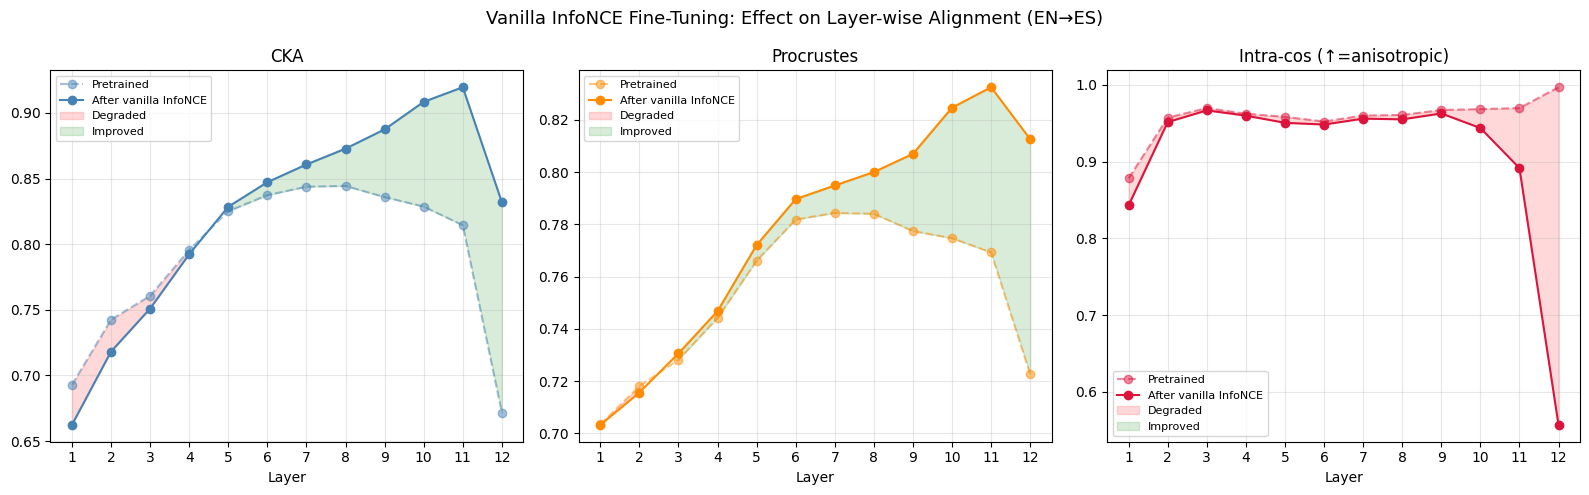

Plot saved to vanilla_infonce_layer_effect.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vanilla InfoNCE Fine-Tuning: Effect on Layer-wise Alignment (EN→ES)', fontsize=13)

metrics = [
    ('cka',        'CKA',                    'steelblue'),
    ('procrustes', 'Procrustes',              'darkorange'),
    ('intra_cos',  'Intra-cos (↑=anisotropic)', 'crimson'),
]

for ax, (key, title, color) in zip(axes, metrics):
    before = results_before[key]
    after  = results_after[key]
    ax.plot(layers, before, marker='o', linestyle='--', color=color,
            alpha=0.5, label='Pretrained')
    ax.plot(layers, after,  marker='o', linestyle='-',  color=color,
            label='After vanilla InfoNCE')
    ax.fill_between(layers, before, after,
                    where=[a < b for a, b in zip(after, before)],
                    alpha=0.15, color='red', label='Degraded')
    ax.fill_between(layers, before, after,
                    where=[a >= b for a, b in zip(after, before)],
                    alpha=0.15, color='green', label='Improved')
    ax.set_title(title)
    ax.set_xlabel('Layer')
    ax.set_xticks(layers)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vanilla_infonce_layer_effect.png', dpi=150)
plt.show()
print('Plot saved to vanilla_infonce_layer_effect.png')

## Step 5: Training Loss Curve

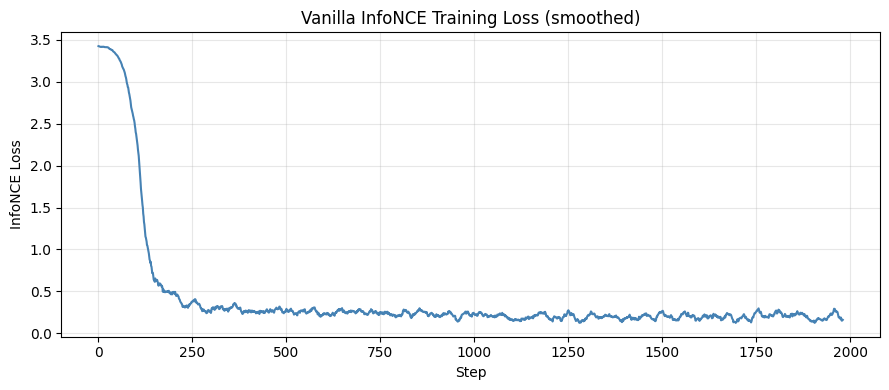

In [13]:
plt.figure(figsize=(9, 4))
smoothed = np.convolve(losses, np.ones(20)/20, mode='valid')
plt.plot(smoothed, color='steelblue')
plt.xlabel('Step')
plt.ylabel('InfoNCE Loss')
plt.title('Vanilla InfoNCE Training Loss (smoothed)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

## Experiment 4: Bystander Language Transfer

After fine-tuning on EN-ES, does alignment improve or degrade for languages the model **never saw during training**?

- **High-resource** bystanders: French (FR), German (DE) — typologically close to Spanish
- **Low-resource** bystanders: Swahili (SW), Arabic (AR) — typologically distant

Hypothesis: fine-tuning on EN-ES may help nearby languages (shared subword vocab, similar syntax) but hurt distant ones (different scripts, no lexical overlap).


In [14]:
# Bystander language FLORES codes
BYSTANDER_LANGS = {
    'FR (high)': ('fra_Latn', 'high-resource'),
    'DE (high)': ('deu_Latn', 'high-resource'),
    'SW (low)':  ('swh_Latn', 'low-resource'),
    'AR (low)':  ('arb_Arab', 'low-resource'),
}

# Need a fresh pretrained model for pre-FT bystander baseline.
# `model` is already fine-tuned; load a clean copy just for scoring.
print('Loading fresh pretrained model for bystander pre-FT baseline...')
pretrained_model = XLMRWrapper('xlm-roberta-base').to(DEVICE)
pretrained_model.eval()
print('Done.\n')

bystander_before = {}
bystander_after  = {}
bystander_pairs_cache = {}

for label, (lang_code, tier) in BYSTANDER_LANGS.items():
    print(f'Loading FLORES EN-{label}...')
    pairs = load_flores_pairs(lang_code, split='dev')
    bystander_pairs_cache[label] = pairs

    bystander_before[label] = run_alignment_check(
        pretrained_model, pairs, label=f'PRETRAINED  EN-{label}')
    bystander_after[label] = run_alignment_check(
        model, pairs, label=f'AFTER FT    EN-{label}')

print('\nBystander alignment checks complete.')

Loading fresh pretrained model for bystander pre-FT baseline...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.

Loading FLORES EN-FR (high)...


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

...

arb_Arab.jsonl: 0.00B [00:00, ?B/s]

arb_Arab.jsonl: 0.00B [00:00, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]


--- PRETRAINED  EN-AR (low) ---
 Layer    Procrustes      Cosine         CKA   Intra-cos
------------------------------------------------------------
     1        0.6788      0.7561      0.6435      0.8782
     2        0.6906      0.9297      0.6938      0.9573
     3        0.6992      0.9633      0.7170      0.9698
     4        0.7122      0.9642      0.7517      0.9623
     5        0.7317      0.9632      0.7760      0.9583
     6        0.7469      0.9606      0.7803      0.9522
     7        0.7488      0.9672      0.7865      0.9601
     8        0.7464      0.9671      0.7791      0.9608
     9        0.7408      0.9753      0.7771      0.9672
    10        0.7356      0.9760      0.7744      0.9684
    11        0.7249      0.9773      0.7456      0.9698
    12        0.6848      0.9965      0.5779      0.9969

--- AFTER FT    EN-AR (low) ---
 Layer    Procrustes      Cosine         CKA   Intra-cos
------------------------------------------------------------
     1        

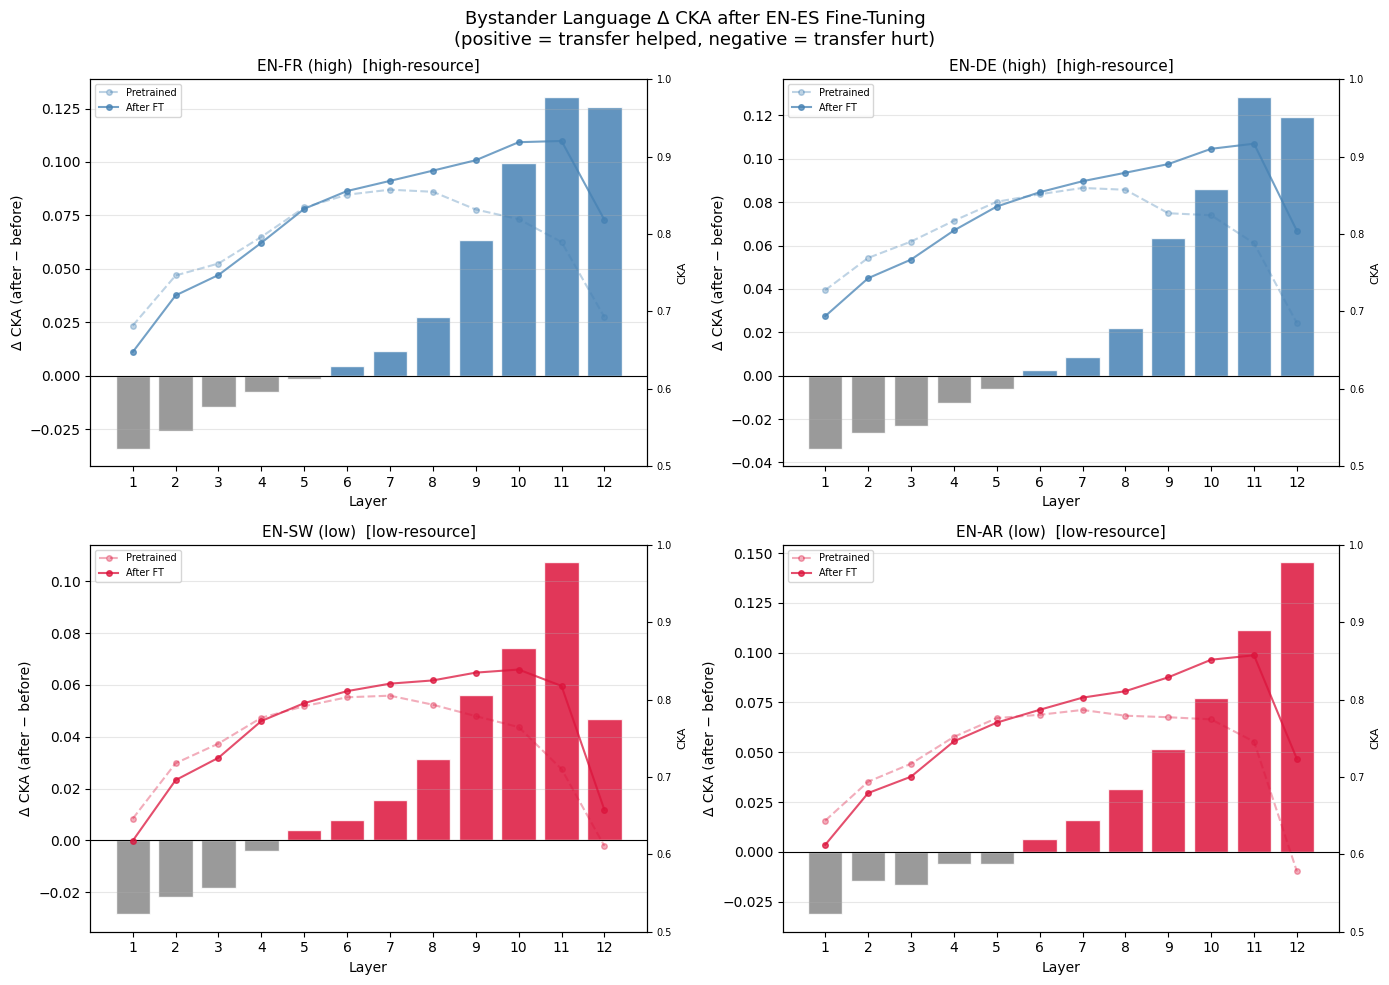

Plot saved to bystander_delta_cka.png

=== Bystander Summary: mean Δ CKA across all 12 layers ===
Language        Tier               mean ΔCKA  Verdict
------------------------------------------------------------
FR (high)       high-resource        +0.0316  ✓ positive transfer
DE (high)       high-resource        +0.0274  ✓ positive transfer
SW (low)        low-resource         +0.0225  ✓ positive transfer
AR (low)        low-resource         +0.0304  ✓ positive transfer
ES (trained)    (training lang)      +0.0323  (reference)


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bystander Language Δ CKA after EN-ES Fine-Tuning\n'
             '(positive = transfer helped, negative = transfer hurt)', fontsize=13)

tier_color = {'high-resource': 'steelblue', 'low-resource': 'crimson'}

for ax, (label, (lang_code, tier)) in zip(axes.flat, BYSTANDER_LANGS.items()):
    before = bystander_before[label]['cka']
    after  = bystander_after[label]['cka']
    delta  = [a - b for a, b in zip(after, before)]
    color  = tier_color[tier]
    bar_colors = [color if d >= 0 else '#888888' for d in delta]
    ax.bar(layers, delta, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    # Also plot absolute CKA curves for reference
    ax2 = ax.twinx()
    ax2.plot(layers, before, 'o--', color=color, alpha=0.35, markersize=4, label='Pretrained')
    ax2.plot(layers, after,  'o-',  color=color, alpha=0.75, markersize=4, label='After FT')
    ax2.set_ylabel('CKA', fontsize=8)
    ax2.set_ylim(0.5, 1.0)
    ax2.tick_params(labelsize=7)
    ax2.legend(fontsize=7, loc='upper left')
    ax.set_title(f'EN-{label}  [{tier}]', fontsize=11)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Δ CKA (after − before)')
    ax.set_xticks(layers)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('bystander_delta_cka.png', dpi=150)
plt.show()
print('Plot saved to bystander_delta_cka.png')

# Summary table
print('\n=== Bystander Summary: mean Δ CKA across all 12 layers ===')
print(f'{"Language":<14}  {"Tier":<16}  {"mean ΔCKA":>10}  {"Verdict"}')
print('-' * 60)
for label, (lang_code, tier) in BYSTANDER_LANGS.items():
    before = bystander_before[label]['cka']
    after  = bystander_after[label]['cka']
    mean_d = sum(a - b for a, b in zip(after, before)) / 12
    verdict = '✓ positive transfer' if mean_d > 0.005 else ('✗ negative transfer' if mean_d < -0.005 else '~ neutral')
    print(f'{label:<14}  {tier:<16}  {mean_d:>+10.4f}  {verdict}')

# Also include EN-ES for comparison
es_mean_d = sum(results_after['cka'][i] - results_before['cka'][i] for i in range(12)) / 12
print(f'{"ES (trained)":<14}  {"(training lang)":<16}  {es_mean_d:>+10.4f}  (reference)')

## Experiment 5: Does Geometric Alignment Translate to Retrieval Accuracy?

**Question:** Does a higher CKA/Procrustes score at a layer actually mean better translation retrieval? And does improving geometric alignment (via fine-tuning) improve real task performance?

**Setup:** Bitext retrieval P@1 — for each source sentence, find the nearest neighbor in the target embedding space. P@1 = fraction of sentences where the correct translation is ranked #1.

Two sub-experiments:
1. **Per-language P@1**: Compare EN-ES (trained) vs bystander languages before and after fine-tuning using the **projection head** (the trained 256-dim space).
2. **Per-layer P@1 on EN-ES**: Compute P@1 from each individual transformer layer's raw representations, then correlate with CKA — does the best-aligned layer also give the best retrieval?


In [16]:
@torch.no_grad()
def compute_p_at_1(mdl, pairs, batch_size=128, use_projection=True):
    """Bitext retrieval P@1.
    use_projection=True  → 256-dim projection head (trained contrastive space)
    use_projection=False → raw last-layer encoder representation
    """
    mdl.eval()
    src_embs, tgt_embs = [], []
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        src_enc, tgt_enc = collate(batch)
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}
        if use_projection:
            src_embs.append(mdl(src_enc['input_ids'], src_enc['attention_mask']))
            tgt_embs.append(mdl(tgt_enc['input_ids'], tgt_enc['attention_mask']))
        else:
            src_reps = mdl.get_all_layer_reps(src_enc['input_ids'], src_enc['attention_mask'])
            tgt_reps = mdl.get_all_layer_reps(tgt_enc['input_ids'], tgt_enc['attention_mask'])
            src_embs.append(src_reps[-1])
            tgt_embs.append(tgt_reps[-1])
    src_all = torch.cat(src_embs, 0)
    tgt_all = torch.cat(tgt_embs, 0)
    sim = src_all @ tgt_all.T
    preds = sim.argmax(dim=1)
    correct = (preds == torch.arange(len(pairs), device=DEVICE)).float()
    return float(correct.mean().item())


# ── Per-language P@1 (projection head) ───────────────────────────────────────
print('Computing per-language P@1 (projection head = trained 256-dim space)...')
print('Note: pretrained_model projection head is random (untrained), so its P@1 is a lower bound.\n')

lang_p1 = {}
print(f'{"Language":<20}  {"P@1 Pretrained":>16}  {"P@1 After FT":>14}  {"Delta":>8}')
print('-' * 68)

# EN-ES (training language)
p1_pre  = compute_p_at_1(pretrained_model, eval_pairs)
p1_post = compute_p_at_1(model, eval_pairs)
delta   = p1_post - p1_pre
lang_p1['EN-ES (trained)'] = (p1_pre, p1_post)
print(f'{"EN-ES (trained)":<20}  {p1_pre:>16.4f}  {p1_post:>14.4f}  {delta:>+8.4f}  ← training language')

# Bystander languages
for label, (lang_code, tier) in BYSTANDER_LANGS.items():
    pairs = bystander_pairs_cache[label]
    p1_pre  = compute_p_at_1(pretrained_model, pairs)
    p1_post = compute_p_at_1(model, pairs)
    delta   = p1_post - p1_pre
    lang_p1[f'EN-{label}'] = (p1_pre, p1_post)
    flag = '✓' if delta > 0 else ('✗' if delta < -0.01 else '~')
    print(f'{"EN-"+label:<20}  {p1_pre:>16.4f}  {p1_post:>14.4f}  {delta:>+8.4f}  {flag} ({tier})')

Computing per-language P@1 (projection head = trained 256-dim space)...
Note: pretrained_model projection head is random (untrained), so its P@1 is a lower bound.

Language                P@1 Pretrained    P@1 After FT     Delta
--------------------------------------------------------------------
EN-ES (trained)                 0.5657          0.9980   +0.4323  ← training language
EN-FR (high)                    0.3852          1.0000   +0.6148  ✓ (high-resource)
EN-DE (high)                    0.5757          0.9950   +0.4193  ✓ (high-resource)
EN-SW (low)                     0.0863          0.8847   +0.7984  ✓ (low-resource)
EN-AR (low)                     0.2909          0.9689   +0.6780  ✓ (low-resource)


In [17]:
@torch.no_grad()
def compute_layer_p_at_1(mdl, pairs, batch_size=128):
    """P@1 retrieval from each individual transformer layer (raw mean-pooled reps)."""
    mdl.eval()
    layer_src = [[] for _ in range(12)]
    layer_tgt = [[] for _ in range(12)]
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        src_enc, tgt_enc = collate(batch)
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}
        src_reps = mdl.get_all_layer_reps(src_enc['input_ids'], src_enc['attention_mask'])
        tgt_reps = mdl.get_all_layer_reps(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        for l in range(12):
            layer_src[l].append(src_reps[l])
            layer_tgt[l].append(tgt_reps[l])
    p1_per_layer = []
    for l in range(12):
        src_all = torch.cat(layer_src[l], 0)
        tgt_all = torch.cat(layer_tgt[l], 0)
        sim = src_all @ tgt_all.T
        preds = sim.argmax(dim=1)
        correct = (preds == torch.arange(src_all.size(0), device=DEVICE)).float()
        p1_per_layer.append(float(correct.mean().item()))
    return p1_per_layer


print('Computing per-layer P@1 on EN-ES (all 997 pairs)...')
layer_p1_pre  = compute_layer_p_at_1(pretrained_model, eval_pairs)
layer_p1_post = compute_layer_p_at_1(model, eval_pairs)

print(f'\n{"Layer":>6}  {"P@1 Pretrained":>16}  {"P@1 After FT":>14}  {"ΔCKA":>8}  {"ΔP@1":>8}')
print('-' * 62)
for i in range(12):
    d_p1  = layer_p1_post[i] - layer_p1_pre[i]
    d_cka = results_after['cka'][i] - results_before['cka'][i]
    print(f'{i+1:>6}  {layer_p1_pre[i]:>16.4f}  {layer_p1_post[i]:>14.4f}  {d_cka:>+8.4f}  {d_p1:>+8.4f}')

Computing per-layer P@1 on EN-ES (all 997 pairs)...

 Layer    P@1 Pretrained    P@1 After FT      ΔCKA      ΔP@1
--------------------------------------------------------------
     1            0.3932          0.3842   -0.0305   -0.0090
     2            0.6520          0.6349   -0.0243   -0.0171
     3            0.8405          0.8776   -0.0097   +0.0371
     4            0.9318          0.9378   -0.0032   +0.0060
     5            0.9669          0.9829   +0.0034   +0.0160
     6            0.9860          0.9950   +0.0098   +0.0090
     7            0.9860          0.9940   +0.0169   +0.0080
     8            0.9890          0.9970   +0.0284   +0.0080
     9            0.9870          0.9980   +0.0516   +0.0110
    10            0.9789          0.9990   +0.0798   +0.0201
    11            0.9268          0.9980   +0.1051   +0.0712
    12            0.7442          0.9920   +0.1603   +0.2477


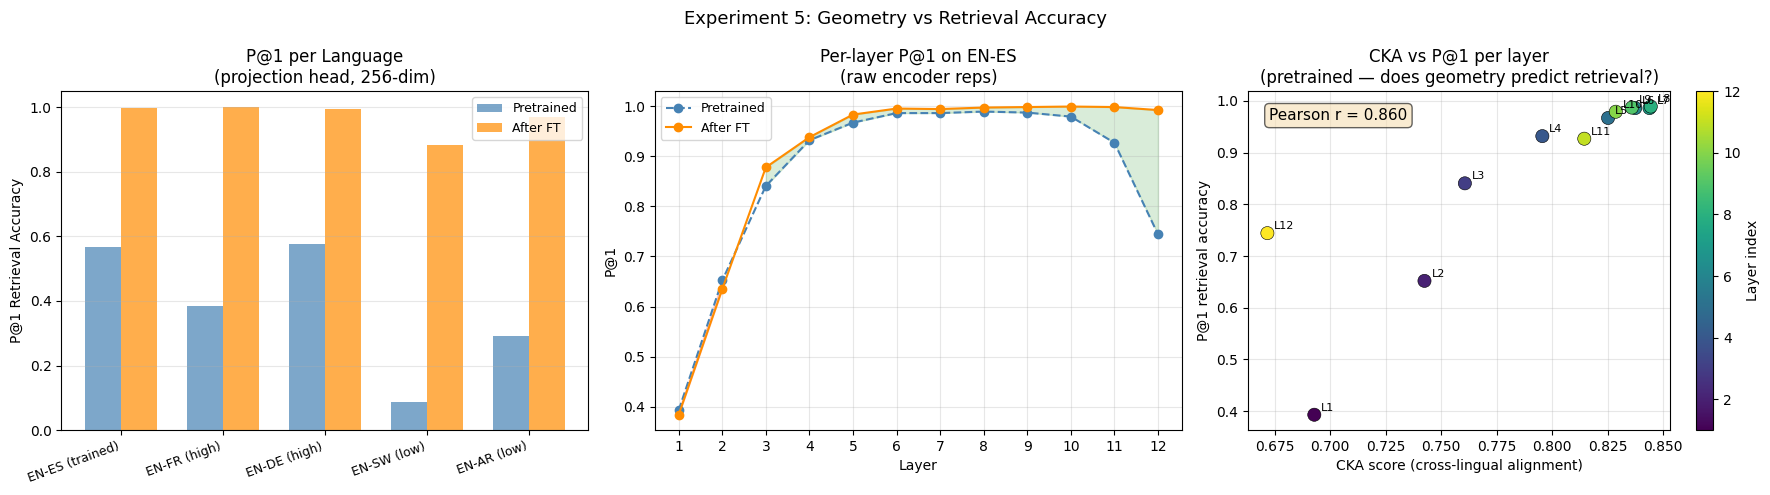

Plot saved to geometry_vs_retrieval.png

Pearson r (CKA vs per-layer P@1, pretrained): 0.860
Interpretation:
  r > 0.7 → geometry strongly predicts retrieval (supports using CKA as signal)
  r ~ 0   → geometry and retrieval are decoupled (CKA is a poor proxy for task perf)
  r < 0   → better-aligned layers actually hurt retrieval (unlikely but informative)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Experiment 5: Geometry vs Retrieval Accuracy', fontsize=13)

# ── Panel 1: Per-language P@1 before/after (projection head) ─────────────────
ax = axes[0]
lang_labels = list(lang_p1.keys())
x = np.arange(len(lang_labels))
w = 0.35
pre_vals  = [lang_p1[l][0] for l in lang_labels]
post_vals = [lang_p1[l][1] for l in lang_labels]
ax.bar(x - w/2, pre_vals,  w, label='Pretrained', color='steelblue',  alpha=0.7)
ax.bar(x + w/2, post_vals, w, label='After FT',   color='darkorange', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(lang_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('P@1 Retrieval Accuracy')
ax.set_title('P@1 per Language\n(projection head, 256-dim)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 2: Per-layer P@1 before/after on EN-ES ─────────────────────────────
ax = axes[1]
ax.plot(layers, layer_p1_pre,  'o--', color='steelblue',  label='Pretrained')
ax.plot(layers, layer_p1_post, 'o-',  color='darkorange', label='After FT')
ax.fill_between(layers, layer_p1_pre, layer_p1_post,
                where=[a > b for a, b in zip(layer_p1_post, layer_p1_pre)],
                alpha=0.15, color='green')
ax.fill_between(layers, layer_p1_pre, layer_p1_post,
                where=[a <= b for a, b in zip(layer_p1_post, layer_p1_pre)],
                alpha=0.15, color='red')
ax.set_xlabel('Layer')
ax.set_ylabel('P@1')
ax.set_title('Per-layer P@1 on EN-ES\n(raw encoder reps)')
ax.set_xticks(layers)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: CKA vs P@1 scatter (pretrained, per layer) ──────────────────────
ax = axes[2]
cka_vals = results_before['cka']
sc = ax.scatter(cka_vals, layer_p1_pre,
                c=layers, cmap='viridis', s=90, zorder=3, edgecolors='black', linewidths=0.4)
for i, (x_val, y_val) in enumerate(zip(cka_vals, layer_p1_pre)):
    ax.annotate(f'L{i+1}', (x_val, y_val),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(sc, ax=ax, label='Layer index')
corr = float(np.corrcoef(cka_vals, layer_p1_pre)[0, 1])
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
ax.set_xlabel('CKA score (cross-lingual alignment)')
ax.set_ylabel('P@1 retrieval accuracy')
ax.set_title('CKA vs P@1 per layer\n(pretrained — does geometry predict retrieval?)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('geometry_vs_retrieval.png', dpi=150)
plt.show()
print(f'Plot saved to geometry_vs_retrieval.png')
print(f'\nPearson r (CKA vs per-layer P@1, pretrained): {corr:.3f}')
print('Interpretation:')
print('  r > 0.7 → geometry strongly predicts retrieval (supports using CKA as signal)')
print('  r ~ 0   → geometry and retrieval are decoupled (CKA is a poor proxy for task perf)')
print('  r < 0   → better-aligned layers actually hurt retrieval (unlikely but informative)')

## Experiment 6: Anisotropy-Corrected Controller Signal

The naive controller assigns LR inversely to CKA score. But two confounds exist:
- **Layers 1–2**: low CKA because they encode surface/subword features — not fixable with more training
- **Layer 12**: low CKA in pretrained model because vectors are anisotropic; fine-tuning "improves" it but mainly by collapsing both languages to the same degenerate direction

A naive inverse-CKA controller gives both **high** LR, which is wrong for layers 1–2 and wasteful for layer 12.

We compare three controller signals to see which assigns LR most sensibly:
1. **Naive** — `score ∝ 1/CKA`, higher for low-CKA layers
2. **Anisotropy-gated** — if `intra_cos > 0.98`, override LR to 0.1x cap; otherwise use inverse-CKA
3. **Peak-relative deficit** — `max(0, CKA_peak − CKA_layer)`, only boosts layers below the peak; everything above gets a floor LR


 Layer       CKA   Intra-cos    Naive×    Gated×    Deficit×
--------------------------------------------------------------
     1    0.6929      0.8782      1.94      2.00        1.82
     2    0.7425      0.9573      1.81      1.87        1.39
     3    0.7607      0.9698      1.77      1.82        1.23
     4    0.7956      0.9623      1.69      1.74        0.92
     5    0.8251      0.9583      1.63      1.68        0.67
     6    0.8374      0.9522      1.60      1.65        0.56
     7    0.8438      0.9601      1.59      1.64        0.50
     8    0.8444      0.9608      1.59      1.64        0.50
     9    0.8359      0.9672      1.61      1.66        0.57
    10    0.8286      0.9684      1.62      1.67        0.64
    11    0.8144      0.9698      1.65      1.70        0.76
    12    0.6718      0.9969      2.00      0.10        2.00 ⚠ aniso

CKA peak at layer 8 (0.8444)
Anisotropy threshold: intra_cos > 0.98 → capped at 0.1x


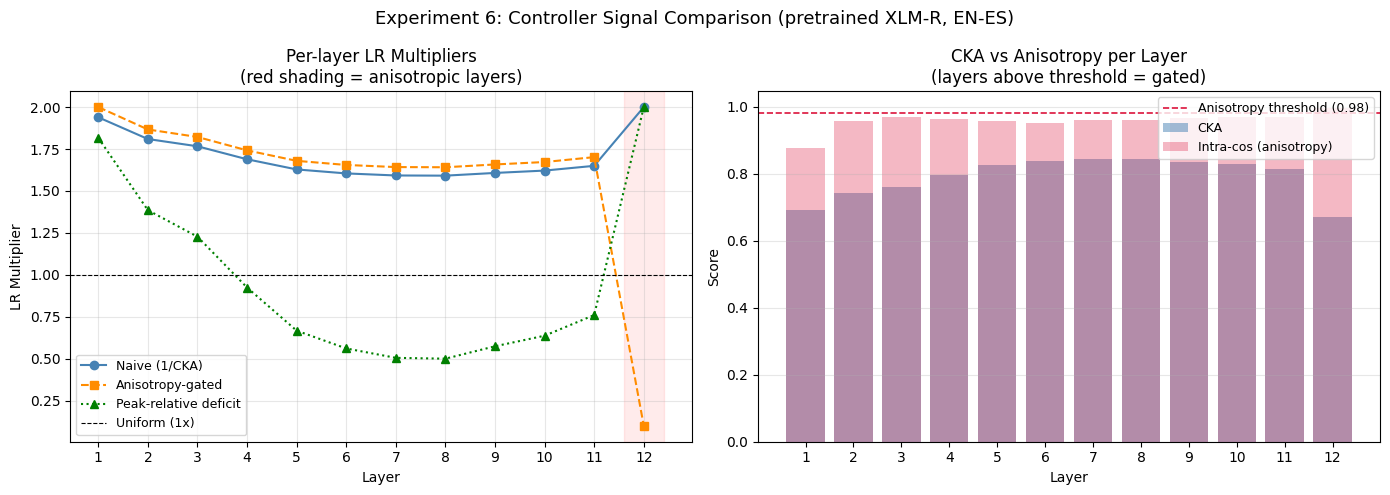

Plot saved to controller_signal_comparison.png

=== Adaptive LR Policy for Experiment 7 (from gated signal) ===
Layers with intra_cos > 0.98 → 0.1x cap
Remaining layers → inverse-CKA, scaled to [0.1, 2.0]

  Layer  1: 2.00x  ██████████
  Layer  2: 1.87x  █████████
  Layer  3: 1.82x  █████████
  Layer  4: 1.74x  ████████
  Layer  5: 1.68x  ████████
  Layer  6: 1.65x  ████████
  Layer  7: 1.64x  ████████
  Layer  8: 1.64x  ████████
  Layer  9: 1.66x  ████████
  Layer 10: 1.67x  ████████
  Layer 11: 1.70x  ████████
  Layer 12: 0.10x  


In [19]:
cka   = results_before['cka']
intra = results_before['intra_cos']
cka_peak = max(cka)

# ── Three controller signals ──────────────────────────────────────────────────
def softmax_normalize(vals, temperature=1.0):
    import math
    exps = [math.exp(v / temperature) for v in vals]
    s = sum(exps)
    return [e / s for e in exps]

# 1. Naive: inverse CKA, softmax normalized → multipliers
naive_raw   = [1.0 / (c + 1e-6) for c in cka]
naive_mults = [v / max(naive_raw) * 2.0 for v in naive_raw]  # scale so max = 2x

# 2. Anisotropy-gated: cap any layer where intra_cos > 0.98
ANISO_THRESH = 0.98
ANISO_CAP    = 0.1
gated_raw = [1.0 / (c + 1e-6) if intra[i] <= ANISO_THRESH else 0.0
             for i, c in enumerate(cka)]
gated_max = max(v for v in gated_raw if v > 0) or 1.0
gated_mults = [ANISO_CAP if intra[i] > ANISO_THRESH
               else max(0.1, (gated_raw[i] / gated_max) * 2.0)
               for i in range(12)]

# 3. Peak-relative deficit: only boost layers below the peak
FLOOR_MULT = 0.5
deficit_raw  = [max(0.0, cka_peak - c) for c in cka]
deficit_max  = max(deficit_raw) or 1.0
deficit_mults = [FLOOR_MULT + (d / deficit_max) * 1.5 for d in deficit_raw]

# ── Print comparison table ────────────────────────────────────────────────────
print(f'{"Layer":>6}  {"CKA":>8}  {"Intra-cos":>10}  '
      f'{"Naive×":>8}  {"Gated×":>8}  {"Deficit×":>10}')
print('-' * 62)
for i in range(12):
    aniso_flag = ' ⚠ aniso' if intra[i] > ANISO_THRESH else ''
    print(f'{i+1:>6}  {cka[i]:>8.4f}  {intra[i]:>10.4f}  '
          f'{naive_mults[i]:>8.2f}  {gated_mults[i]:>8.2f}  {deficit_mults[i]:>10.2f}'
          f'{aniso_flag}')

print(f'\nCKA peak at layer {cka.index(cka_peak)+1} ({cka_peak:.4f})')
print(f'Anisotropy threshold: intra_cos > {ANISO_THRESH} → capped at {ANISO_CAP}x')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 6: Controller Signal Comparison (pretrained XLM-R, EN-ES)', fontsize=13)

ax = axes[0]
ax.plot(layers, naive_mults,   'o-',  color='steelblue',  label='Naive (1/CKA)')
ax.plot(layers, gated_mults,   's--', color='darkorange', label='Anisotropy-gated')
ax.plot(layers, deficit_mults, '^:',  color='green',      label='Peak-relative deficit')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='Uniform (1x)')
# Shade anisotropic layers
for i in range(12):
    if intra[i] > ANISO_THRESH:
        ax.axvspan(i + 0.6, i + 1.4, alpha=0.08, color='red')
ax.set_xlabel('Layer')
ax.set_ylabel('LR Multiplier')
ax.set_title('Per-layer LR Multipliers\n(red shading = anisotropic layers)')
ax.set_xticks(layers)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(layers, cka,   alpha=0.5, color='steelblue', label='CKA')
ax.bar(layers, intra, alpha=0.3, color='crimson',   label='Intra-cos (anisotropy)')
ax.axhline(ANISO_THRESH, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Anisotropy threshold ({ANISO_THRESH})')
ax.set_xlabel('Layer')
ax.set_ylabel('Score')
ax.set_title('CKA vs Anisotropy per Layer\n(layers above threshold = gated)')
ax.set_xticks(layers)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('controller_signal_comparison.png', dpi=150)
plt.show()
print('Plot saved to controller_signal_comparison.png')

# ── Derive the policy for Experiment 7 ───────────────────────────────────────
print('\n=== Adaptive LR Policy for Experiment 7 (from gated signal) ===')
print('Layers with intra_cos > 0.98 → 0.1x cap')
print('Remaining layers → inverse-CKA, scaled to [0.1, 2.0]\n')
EXP7_MULTIPLIERS = gated_mults
for i, m in enumerate(EXP7_MULTIPLIERS):
    bar = '█' * int(m * 5)
    print(f'  Layer {i+1:>2}: {m:.2f}x  {bar}')

## Experiment 7: Preliminary Adaptive LR Run

Using the anisotropy-gated multipliers from Experiment 6, we run 2000 steps of InfoNCE with a **static per-layer LR policy** derived from our analysis of the pretrained model.

This is not the full adaptive system (no periodic recomputation), but it tests the core claim: *does redistributing the optimizer budget according to geometry produce better outcomes than uniform LR?*

Comparison: **Vanilla InfoNCE** (uniform LR, `model`) vs **Adaptive LR** (gated multipliers, `adaptive_model`).


In [24]:
# Free GPU memory — move other models to CPU before training.
import gc
print('Moving other models to CPU to free VRAM...')
model.cpu()
pretrained_model.cpu()
# Clean up any leftover adaptive_model from a previous failed run
for _name in ['adaptive_model', 'adaptive_optimizer', 'adaptive_scheduler']:
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()
print(f'Free VRAM: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB\n')

# Deep-copy pretrained_model (on CPU) → adaptive_model on GPU
adaptive_model = copy.deepcopy(pretrained_model).to(DEVICE)

# ── Build per-layer parameter groups ─────────────────────────────────────────
param_groups = [
    {'params': list(adaptive_model.projection.parameters()), 'lr': LR},
    {'params': list(adaptive_model.model.embeddings.parameters()),
     'lr': LR * EXP7_MULTIPLIERS[0]},
]
for layer_idx in range(12):
    param_groups.append({
        'params': list(adaptive_model.model.encoder.layer[layer_idx].parameters()),
        'lr': LR * EXP7_MULTIPLIERS[layer_idx],
    })

adaptive_optimizer = AdamW(param_groups, weight_decay=0.01)
adaptive_scheduler = get_linear_schedule_with_warmup(
    adaptive_optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=MAX_STEPS)

print('Per-layer LR assignments:')
print(f'  {"Group":<20}  {"LR":>10}  {"Mult":>6}')
print('-' * 42)
print(f'  {"projection":<20}  {LR:>10.2e}  {"1.00":>6}')
print(f'  {"embeddings":<20}  {LR*EXP7_MULTIPLIERS[0]:>10.2e}  {EXP7_MULTIPLIERS[0]:>6.2f}')
for i in range(12):
    print(f'  {f"encoder.layer.{i}":<20}  {LR*EXP7_MULTIPLIERS[i]:>10.2e}  {EXP7_MULTIPLIERS[i]:>6.2f}')

# ── Training loop ─────────────────────────────────────────────────────────────
adaptive_model.train()
train_iter2 = opus_stream('en-es', seed=123)
batch_buffer2 = []
adaptive_losses = []
step2 = 0

print(f'\nStarting adaptive LR fine-tuning for {MAX_STEPS} steps...')

for src_text, tgt_text in train_iter2:
    batch_buffer2.append((src_text, tgt_text))
    if len(batch_buffer2) < BATCH_SIZE:
        continue

    src_enc, tgt_enc = collate(batch_buffer2)
    batch_buffer2 = []

    src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
    tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}

    z_src = adaptive_model(src_enc['input_ids'], src_enc['attention_mask'])
    z_tgt = adaptive_model(tgt_enc['input_ids'], tgt_enc['attention_mask'])
    loss = infonce_loss(z_src, z_tgt)

    adaptive_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(adaptive_model.parameters(), 1.0)
    adaptive_optimizer.step()
    adaptive_scheduler.step()

    step2 += 1
    adaptive_losses.append(loss.item())

    if step2 % LOG_EVERY == 0:
        avg = sum(adaptive_losses[-LOG_EVERY:]) / LOG_EVERY
        print(f'  step {step2:>4}/{MAX_STEPS}  loss={avg:.4f}')

    if step2 >= MAX_STEPS:
        break

# Delete optimizer immediately — frees ~2 GB needed for eval
del adaptive_optimizer, adaptive_scheduler
gc.collect()
torch.cuda.empty_cache()
print(f'\nTraining complete. VRAM after optimizer cleanup: '
      f'{(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.2f} GB')

Moving other models to CPU to free VRAM...
Free VRAM: 9.29 GB

Per-layer LR assignments:
  Group                         LR    Mult
------------------------------------------
  projection              2.00e-05    1.00
  embeddings              4.00e-05    2.00
  encoder.layer.0         4.00e-05    2.00
  encoder.layer.1         3.73e-05    1.87
  encoder.layer.2         3.64e-05    1.82
  encoder.layer.3         3.48e-05    1.74
  encoder.layer.4         3.36e-05    1.68
  encoder.layer.5         3.31e-05    1.65
  encoder.layer.6         3.28e-05    1.64
  encoder.layer.7         3.28e-05    1.64
  encoder.layer.8         3.32e-05    1.66
  encoder.layer.9         3.34e-05    1.67
  encoder.layer.10        3.40e-05    1.70
  encoder.layer.11        2.00e-06    0.10

Starting adaptive LR fine-tuning for 2000 steps...
  step  100/2000  loss=3.1889
  step  200/2000  loss=0.8519
  step  300/2000  loss=0.3595
  step  400/2000  loss=0.3063
  step  500/2000  loss=0.2858
  step  600/2000  los

In [25]:
# Only adaptive_model is on GPU. results_before, results_after, layer_p1_pre,
# layer_p1_post are already computed from earlier cells — no need to re-eval.
results_adaptive  = run_alignment_check(adaptive_model, eval_pairs, label='AFTER adaptive LR (2000 steps)')
layer_p1_adaptive = compute_layer_p_at_1(adaptive_model, eval_pairs)

# ── 3-way comparison table ────────────────────────────────────────────────────
print('\n=== 3-WAY COMPARISON: Pretrained / Vanilla FT / Adaptive FT ===')
print(f'{"Layer":>6}  {"CKA Pre":>9}  {"CKA Van":>9}  {"CKA Adp":>9}  '
      f'{"P@1 Pre":>9}  {"P@1 Van":>9}  {"P@1 Adp":>9}  {"Winner"}')
print('-' * 80)
for i in range(12):
    cp = results_before['cka'][i]
    cv = results_after['cka'][i]
    ca = results_adaptive['cka'][i]
    pp = layer_p1_pre[i]
    pv = layer_p1_post[i]
    pa = layer_p1_adaptive[i]
    winner = 'Adaptive' if ca >= cv + 0.002 else ('Vanilla' if cv >= ca + 0.002 else 'tie')
    print(f'{i+1:>6}  {cp:>9.4f}  {cv:>9.4f}  {ca:>9.4f}  '
          f'{pp:>9.4f}  {pv:>9.4f}  {pa:>9.4f}  {winner}')

van_mean_cka = sum(results_after['cka']) / 12
adp_mean_cka = sum(results_adaptive['cka']) / 12
van_mean_p1  = sum(layer_p1_post) / 12
adp_mean_p1  = sum(layer_p1_adaptive) / 12

print(f'\n{"MEAN":>6}  {"":>9}  {van_mean_cka:>9.4f}  {adp_mean_cka:>9.4f}  '
      f'{"":>9}  {van_mean_p1:>9.4f}  {adp_mean_p1:>9.4f}')
print(f'\nAdaptive vs Vanilla  |  ΔCKA: {adp_mean_cka - van_mean_cka:+.4f}  |  ΔP@1: {adp_mean_p1 - van_mean_p1:+.4f}')

# Key question: did adaptive better protect layers 1-2?
d_van_early = sum(results_after['cka'][i]    - results_before['cka'][i] for i in range(2)) / 2
d_adp_early = sum(results_adaptive['cka'][i] - results_before['cka'][i] for i in range(2)) / 2
print(f'\nLayers 1-2 mean ΔCKA — Vanilla: {d_van_early:+.4f}  Adaptive: {d_adp_early:+.4f}')
print('(Adaptive should show less damage here — this is the core claim)')


--- AFTER adaptive LR (2000 steps) ---
 Layer    Procrustes      Cosine         CKA   Intra-cos
------------------------------------------------------------
     1        0.7018      0.8106      0.6530      0.8280
     2        0.7145      0.9542      0.7087      0.9482
     3        0.7298      0.9755      0.7439      0.9622
     4        0.7469      0.9764      0.7889      0.9541
     5        0.7727      0.9765      0.8299      0.9419
     6        0.7895      0.9794      0.8461      0.9410
     7        0.7970      0.9835      0.8643      0.9478
     8        0.8045      0.9844      0.8775      0.9433
     9        0.8119      0.9898      0.8898      0.9526
    10        0.8205      0.9908      0.9003      0.9435
    11        0.8263      0.9814      0.9047      0.8448
    12        0.8031      0.9289      0.7980      0.5012

=== 3-WAY COMPARISON: Pretrained / Vanilla FT / Adaptive FT ===
 Layer    CKA Pre    CKA Van    CKA Adp    P@1 Pre    P@1 Van    P@1 Adp  Winner
------------

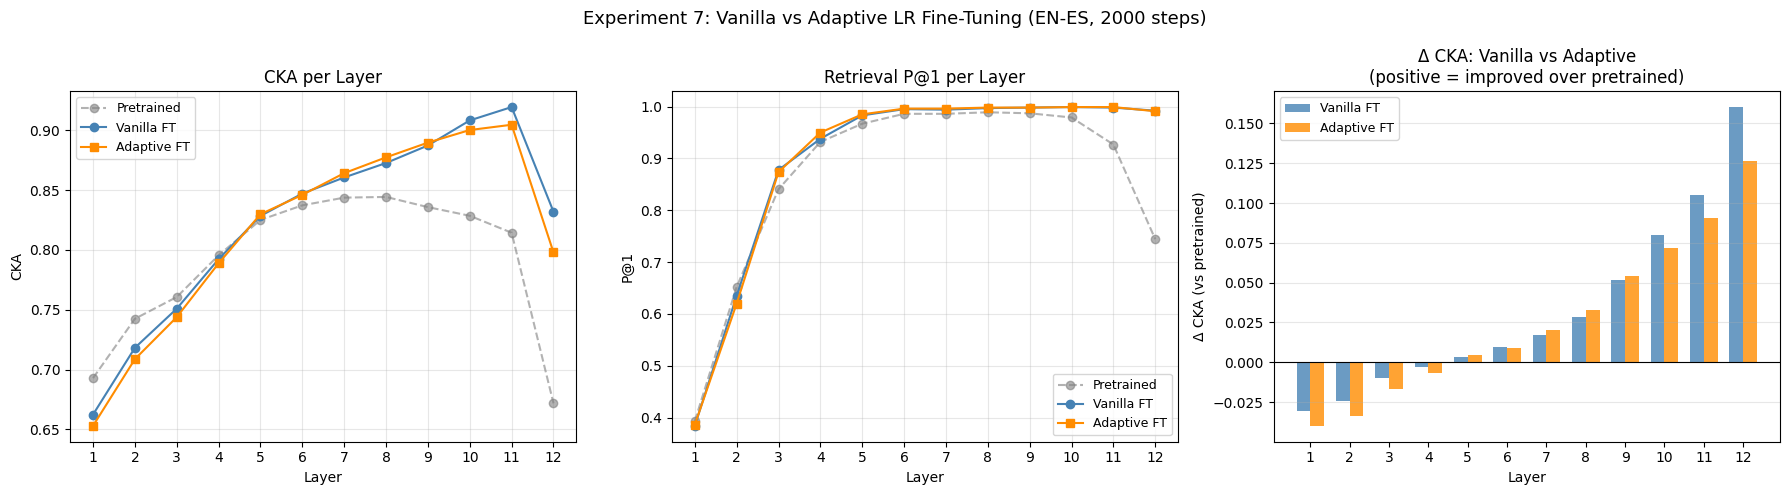

Plot saved to adaptive_vs_vanilla.png


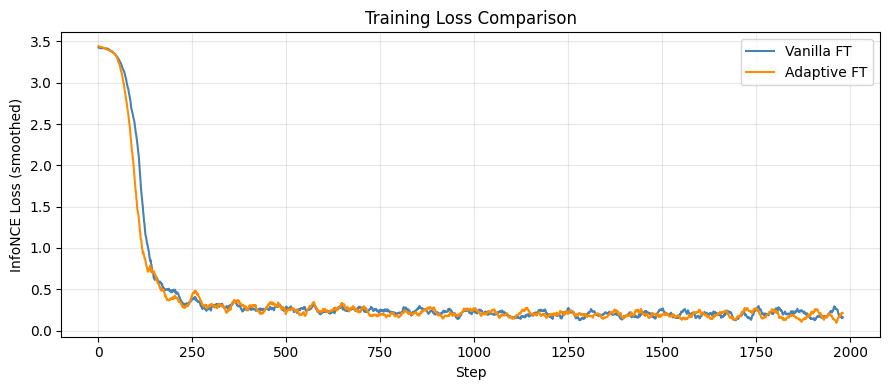

Loss comparison saved to loss_comparison.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Experiment 7: Vanilla vs Adaptive LR Fine-Tuning (EN-ES, 2000 steps)', fontsize=13)

# ── Panel 1: CKA per layer ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(layers, results_before['cka'],   'o--', color='gray',       alpha=0.6, label='Pretrained')
ax.plot(layers, results_after['cka'],    'o-',  color='steelblue',  label='Vanilla FT')
ax.plot(layers, results_adaptive['cka'], 's-',  color='darkorange', label='Adaptive FT')
ax.set_xlabel('Layer')
ax.set_ylabel('CKA')
ax.set_title('CKA per Layer')
ax.set_xticks(layers)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: Per-layer P@1 ────────────────────────────────────────────────────
ax = axes[1]
ax.plot(layers, layer_p1_pre,      'o--', color='gray',       alpha=0.6, label='Pretrained')
ax.plot(layers, layer_p1_post,     'o-',  color='steelblue',  label='Vanilla FT')
ax.plot(layers, layer_p1_adaptive, 's-',  color='darkorange', label='Adaptive FT')
ax.set_xlabel('Layer')
ax.set_ylabel('P@1')
ax.set_title('Retrieval P@1 per Layer')
ax.set_xticks(layers)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: Delta CKA (vs pretrained) side-by-side ──────────────────────────
ax = axes[2]
x = np.arange(12)
w = 0.35
delta_van = [results_after['cka'][i]    - results_before['cka'][i] for i in range(12)]
delta_adp = [results_adaptive['cka'][i] - results_before['cka'][i] for i in range(12)]
ax.bar(x - w/2, delta_van, w, label='Vanilla FT',   color='steelblue',  alpha=0.8)
ax.bar(x + w/2, delta_adp, w, label='Adaptive FT',  color='darkorange', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Layer')
ax.set_ylabel('Δ CKA (vs pretrained)')
ax.set_title('Δ CKA: Vanilla vs Adaptive\n(positive = improved over pretrained)')
ax.set_xticks(x)
ax.set_xticklabels([str(l) for l in layers])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('adaptive_vs_vanilla.png', dpi=150)
plt.show()
print('Plot saved to adaptive_vs_vanilla.png')

# ── Loss curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
s1 = np.convolve(losses,          np.ones(20)/20, mode='valid')
s2 = np.convolve(adaptive_losses, np.ones(20)/20, mode='valid')
plt.plot(s1, color='steelblue',  label='Vanilla FT')
plt.plot(s2, color='darkorange', label='Adaptive FT')
plt.xlabel('Step')
plt.ylabel('InfoNCE Loss (smoothed)')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150)
plt.show()
print('Loss comparison saved to loss_comparison.png')